In [1]:
using LinearAlgebra
using QuantumToolbox
using GLMakie
using Plots
using DifferentialEquations


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
A = [0.5 0.5 0.25; 0.25 0 0.25; 0.25 0.5 0.5]

xtoday = [1; 0; 0]
for i in range(1,50,50) 
    xtomorrow = A*xtoday
    xtoday = xtomorrow
    print(i , xtoday)
end



1.0[0.5, 0.25, 0.25]2.0[0.4375, 0.1875, 0.375]3.0[0.40625, 0.203125, 0.390625]4.0[0.40234375, 0.19921875, 0.3984375]5.0[0.400390625, 0.2001953125, 0.3994140625]6.0[0.400146484375, 0.199951171875, 0.39990234375]7.0[0.4000244140625, 0.20001220703125, 0.39996337890625]8.0[0.4000091552734375, 0.1999969482421875, 0.399993896484375]9.0[0.40000152587890625, 0.20000076293945312, 0.3999977111816406]10.0[0.40000057220458984, 0.19999980926513672, 0.39999961853027344]11.0[0.40000009536743164, 0.20000004768371582, 0.39999985694885254]12.0[0.40000003576278687, 0.19999998807907104, 0.3999999761581421]13.0[0.4000000059604645, 0.20000000298023224, 0.3999999910593033]14.0[0.4000000022351742, 0.19999999925494194, 0.3999999985098839]15.0[0.40000000037252903, 0.20000000018626451, 0.39999999944120646]16.0[0.4000000001396984, 0.19999999995343387, 0.39999999990686774]17.0[0.40000000002328306, 0.20000000001164153, 0.3999999999650754]18.0[0.40000000000873115, 0.19999999999708962, 0.39999999999417923]19.0[0.4000

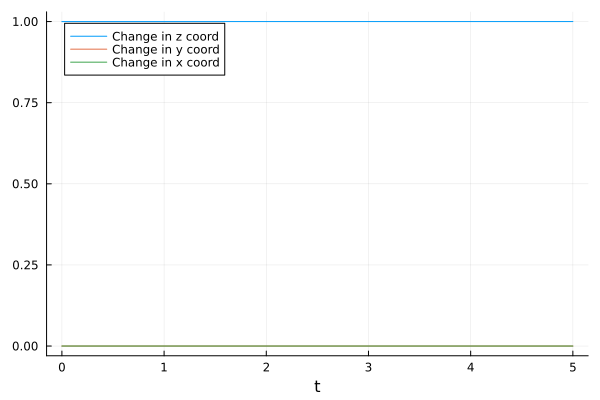

In [118]:
H = sigmaz()
ψ0 = basis(2, 0)
e_ops = [
    proj(basis(2, 0)),
    proj(basis(2, 1)),
    basis(2, 0) * basis(2, 1)'
]
#the second part of the LinRange is the farthest right x coordinate
tlist = LinRange(0, 5, 100)
sol = sesolve(H, ψ0, tlist, e_ops = e_ops, progress_bar = Val(false))

exp1 = real(sol.expect[1,:])
exp2 = real(sol.expect[2,:])
exp3 = real(sol.expect[3,:])

times = sol.times
Plots.plot(times, exp1, label = "Change in z coord", xlabel = "t")
Plots.plot!(times, exp2, label = "Change in y coord")
Plots.plot!(times, exp3, label = "Change in x coord")

# for i in range(1,100)
#     if exp1[i]>0.98
#         print("\n")
#         print(i)
#         print("\n")
#         print(exp1[i])
#     end
# end

#green is x coordinate
#this graph represents the probablity nad expected value of the rotating bloch sphere vector psi
#the state starts in the zero ket state and then while holding the x axis, rotate with time around the x axis 
#this will lead the y and z coordinates to change 
# this makes them on the bloch sphere have different probabilities to go to the zero and one state
# this means that as the sphere is rotated, the z coordinate decreases and the y coordinate increases leading to a different probability to go to zero and one


#when H is sigmaz then the bloch sphere spins around the z axis but since psi is at the pole, there is no change in the coordinates of anything


In [3]:
dot_List = [0 -2 2; 2 0 -2; -2 2 0]
A_List = [0 -0.2 -0.2; -0.2 0 -0.2; -0.2 -0.2 0]

# function y_gate(du, u, p, t)
#     du[1] = 2 * u[3] 
#     du[2] = 0
#     du[3] = -2 * u[1]
# end

# function gate_and_interfence(du, u, p, t)
#     du[1] = dot_List[2,1] * u[3] 
#     du[2] = dot_List[2,2]*u[2] -0.2 * u[2]
#     du[3] = dot_List[2,3]* u[1] - (0.2*u[3])
# end


#every time to create a new animation you have to change the index of the dot list first position and the order of the u[x] since this REALLY MATTERS
u_yz0 = [1; 0; 0]
u_xz0 = [0; 1; 0]
u_xy0 = [0; 0; 1]


function Chooser(string)
    if string == "X"
        return [1, 1, 3, 2,u_xy0]
    end
     if string == "Y"
        return [2, 3, 2, 1,u_yz0]
    end
     if string == "Z"
        return [3, 2, 1, 3,u_xz0]
    end
end

function interChoose(string)
    if string == "X"
        return [1,1]
    end
     if string == "Y"
        return [2,1]
    end
     if string == "Z"
        return [3,1]
    end
    if string != "Z" 
        return [1,0]
    end
end

Gate_Chosen = Chooser("Z")
inter_Chosen = interChoose("")

function Gate_and_Interfence(du, u, p, t)
    du[1] = dot_List[Gate_Chosen[1],1] * u[Gate_Chosen[2]] + inter_Chosen[2] * (A_List[inter_Chosen[1],1] * u[1])
    du[2] = dot_List[Gate_Chosen[1],2] * u[Gate_Chosen[3]] + inter_Chosen[2] * (A_List[inter_Chosen[1],2] * u[2])
    du[3] = dot_List[Gate_Chosen[1],3] * u[Gate_Chosen[4]] + inter_Chosen[2] * (A_List[inter_Chosen[1],3] * u[3])
end

import DifferentialEquations as DE


tspan = (0.0, 10.0)
prob = DE.ODEProblem(Gate_and_Interfence, Gate_Chosen[5], tspan)
sol = DE.solve(prob)


b = Bloch()
b.view = [50,30]
fig, lscene = render(b)
record(fig, "Z_gate.mp4", 1:length(sol.t), framerate = 20) do idx
     clear!(b)
     empty!(lscene)
     vec = sol.u[idx]
     add_vectors!(b, vec)
     render(b, location = lscene)
 end


"Z_gate.mp4"